In [1]:
pip install lightgbm scikit-learn pandas numpy matplotlib seaborn

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

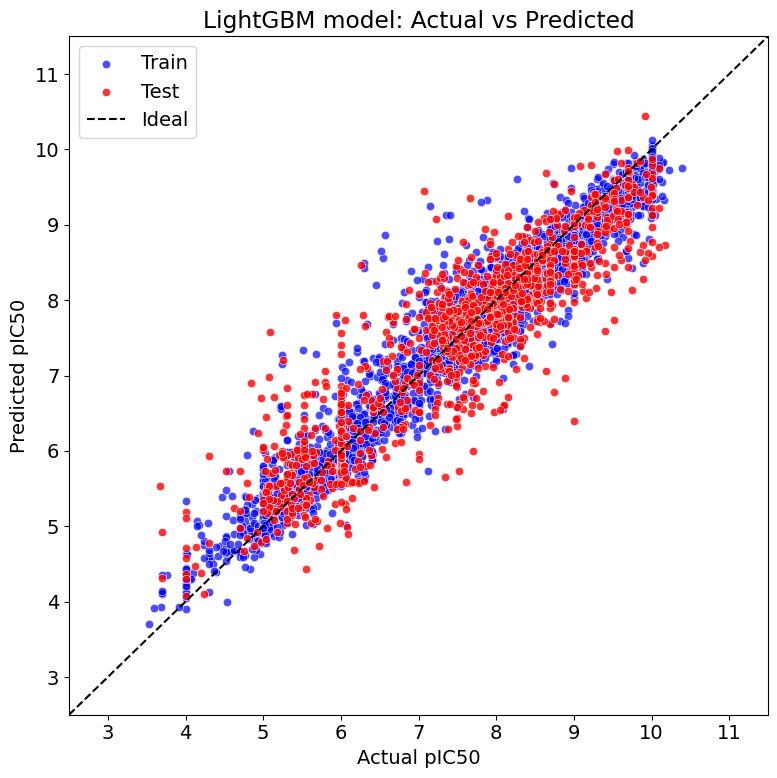

          Model  R² Train  R² Test  Q² Train  RMSE Train  RMSE Test  MAE Train  MAE Test                                                 Best Params
TopModel_Seed_7    0.9315   0.8163    0.7845      0.3678     0.5967     0.2648    0.4506 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────
dataset_path = "MDM2_main_input.csv"
data = pd.read_csv(dataset_path)

# FIX #2: Drop NaN rows BEFORE separating Smiles so indices stay aligned
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

# Separate Smiles AFTER dropna so it shares the same index as X and y
smiles = data['Smiles'].copy() if 'Smiles' in data.columns else None
data = data.drop(columns=['Smiles'], errors='ignore')

# Separate features and target
target_column = 'pIC50'
X = data.drop(columns=[target_column])
y = data[target_column]

print(f"Dataset loaded: {X.shape[0]} compounds, {X.shape[1]} raw descriptors")

# ─────────────────────────────────────────────
# 2. Train / Validation split FIRST
#    (validation set must be set aside before ANY feature selection)
# FIX #3: Feature selection is deferred until after the split
# ─────────────────────────────────────────────
if smiles is not None:
    X_temp, X_val, y_temp, y_val, smiles_temp, smiles_val = train_test_split(
        X, y, smiles, test_size=0.2, random_state=42
    )
else:
    X_temp, X_val, y_temp, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    smiles_temp = smiles_val = None


print(f"Train+Test: {len(X_temp)}  |  Validation (held-out): {len(X_val)}")

# ─────────────────────────────────────────────
# 3. Feature selection fitted ONLY on X_temp (80%)
#    then applied to both X_temp and X_val
# ─────────────────────────────────────────────

# Step A: remove low-variance features
vt = VarianceThreshold(threshold=0.01)
X_temp_reduced = pd.DataFrame(
    vt.fit_transform(X_temp),
    columns=X_temp.columns[vt.get_support()],
    index=X_temp.index
)
# Apply the same mask to validation set
X_val_reduced = pd.DataFrame(
    vt.transform(X_val),
    columns=X_temp.columns[vt.get_support()],
    index=X_val.index
)
print(f"After VarianceThreshold: {X_temp_reduced.shape[1]} descriptors")

# Step B: remove highly correlated features (correlation computed on X_temp only)
corr_matrix = X_temp_reduced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

X_temp_filtered = X_temp_reduced.drop(columns=to_drop)
X_val_filtered  = X_val_reduced.drop(columns=to_drop)
print(f"After Correlation Filter: {X_temp_filtered.shape[1]} descriptors")

# Step C: LightGBM Importance Filtering (fit on X_temp only — no leakage)
TOP_N = 50   # adjust: ~5–10 compounds per descriptor recommended
pre_screen = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
pre_screen.fit(X_temp_filtered, y_temp)

importances = pd.Series(
    pre_screen.feature_importances_,
    index=X_temp_filtered.columns
).sort_values(ascending=False)

top_descriptors = importances.head(TOP_N).index.tolist()

X_temp_filtered = X_temp_filtered[top_descriptors]
X_val_filtered  = X_val_filtered[top_descriptors]
print(f"After Importance Filtering (top {TOP_N}): {X_temp_filtered.shape[1]} descriptors")

# Save final selected feature names
pd.DataFrame({'feature': top_descriptors}).to_csv("features_used.csv", index=False)
print("Feature names saved to: features_used.csv")

# ─────────────────────────────────────────────
# 4. Save untouched validation set
# ─────────────────────────────────────────────
val_df = X_val_filtered.copy()
val_df['Actual'] = y_val.values
if smiles_val is not None:
    val_df['Smiles'] = smiles_val.values
val_df.to_csv("validation_set_untouched.csv", index=False)
print("Validation set saved to: validation_set_untouched.csv")

# ─────────────────────────────────────────────
# 5. Helper: Q² via K-Fold CV using fixed params
#    (honest estimate — computed on the passed-in split)
# ─────────────────────────────────────────────
def calculate_q2_train(X, y, params, seed):
    """Cross-validated R² (Q²) computed on the TRAINING set only."""
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    q2_preds = np.zeros(len(y))
    for train_idx, val_idx in kf.split(X):
        model = LGBMRegressor(random_state=seed, **params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        q2_preds[val_idx] = model.predict(X.iloc[val_idx])
    return r2_score(y, q2_preds)

# ─────────────────────────────────────────────
# 6. Helper: build output DataFrame
#    FIX #6: None-guard for smiles
# ─────────────────────────────────────────────
def create_output_df(X, y, y_pred, smiles_series, dataset_name):
    df = pd.DataFrame({
        'Actual':    y.values,
        'Predicted': y_pred,
        'Set':       dataset_name
    })
    if smiles_series is not None:
        df.insert(0, 'Smiles', smiles_series.values)
    return df

# ─────────────────────────────────────────────
# 7. Model building over 10 random seeds
# ─────────────────────────────────────────────
results = []

for seed in range(10):
    if smiles_temp is not None:
        X_train, X_test, y_train, y_test, smiles_train, smiles_test = train_test_split(
            X_temp_filtered, y_temp, smiles_temp,
            test_size=0.25, random_state=seed
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_temp_filtered, y_temp,
            test_size=0.25, random_state=seed
        )
        smiles_train = smiles_test = None

    param_grid = {
        'n_estimators':  [100, 200],
        'max_depth':     [3, 5],
        'learning_rate': [0.05, 0.1]
    }

    grid_search = GridSearchCV(
        LGBMRegressor(random_state=seed),
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # FIX #1: GridSearchCV already re-fits best_estimator_ on full X_train.
    # No second .fit() needed — use best_estimator_ directly.
    best_model  = grid_search.best_estimator_
    best_params = grid_search.best_params_

    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)

    # Q² computed on TRAIN set via cross-validation (correct QSAR definition)
    q2_train = calculate_q2_train(
        X_train.reset_index(drop=True),
        y_train.reset_index(drop=True),
        best_params, seed
    )

    results.append({
        'seed':         seed,
        'model':        best_model,
        'params':       best_params,
        'r2_train':     r2_score(y_train, y_train_pred),
        'r2_test':      r2_score(y_test,  y_test_pred),
        'q2_train':     q2_train,
        'rmse_train':   np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'rmse_test':    np.sqrt(mean_squared_error(y_test,  y_test_pred)),
        'mae_train':    mean_absolute_error(y_train, y_train_pred),
        'mae_test':     mean_absolute_error(y_test,  y_test_pred),
        'X_train':      X_train,
        'X_test':       X_test,
        'y_train':      y_train,
        'y_test':       y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred':  y_test_pred,
        'smiles_train': smiles_train,
        'smiles_test':  smiles_test,
    })
    print(f"Seed {seed:2d} | R² Train: {results[-1]['r2_train']:.4f} | "
          f"R² Test: {results[-1]['r2_test']:.4f} | Q² Train: {q2_train:.4f}")

# ─────────────────────────────────────────────
# 8. Select best model by R² test score
# ─────────────────────────────────────────────
top_model = max(results, key=lambda x: x['r2_test'])
prefix    = f"LightGBM model{top_model['seed']}"
print(f"\nBest model: Seed {top_model['seed']} | R² Test: {top_model['r2_test']:.4f}")

# ─────────────────────────────────────────────
# 9. Save Train / Test CSVs and combined file
# ─────────────────────────────────────────────
def create_output_df_full(X, y, y_pred, smiles_series, dataset_name):
    df = X.copy()                          # ← includes all descriptor columns
    df['Actual']    = y.values
    df['Predicted'] = y_pred
    df['Set']       = dataset_name
    if smiles_series is not None:
        df.insert(0, 'Smiles', smiles_series.values)
    return df

train_out = create_output_df_full(
    top_model['X_train'], top_model['y_train'],
    top_model['y_train_pred'], top_model['smiles_train'], 'Train'
)
test_out = create_output_df_full(
    top_model['X_test'], top_model['y_test'],
    top_model['y_test_pred'], top_model['smiles_test'], 'Test'
)

train_out.to_csv("train_set.csv", index=False)
test_out.to_csv("test_set.csv",   index=False)
pd.concat([train_out, test_out], ignore_index=True).to_csv(
    "top_lightgbm_actual_vs_predicted.csv", index=False
)

# ─────────────────────────────────────────────
# 10. Actual vs Predicted plot
# ─────────────────────────────────────────────
all_actual    = np.concatenate([top_model['y_train'], top_model['y_test']])
all_predicted = np.concatenate([top_model['y_train_pred'], top_model['y_test_pred']])
axis_min = float(np.floor(min(all_actual.min(), all_predicted.min()))) - 0.5
axis_max = float(np.ceil( max(all_actual.max(), all_predicted.max()))) + 0.5

plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})
sns.scatterplot(x=top_model['y_train'], y=top_model['y_train_pred'],
                label='Train', color='blue',  alpha=0.7)
sns.scatterplot(x=top_model['y_test'],  y=top_model['y_test_pred'],
                label='Test',  color='red', alpha=0.8)
plt.plot([axis_min, axis_max], [axis_min, axis_max], 'k--', label='Ideal')
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title('LightGBM model: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig("LightGBM_model_plot.png", dpi=300)
plt.show()

# ─────────────────────────────────────────────
# 11. Save summary
# ─────────────────────────────────────────────
summary_df = pd.DataFrame([{
    'Model':       f"TopModel_Seed_{top_model['seed']}",
    'R² Train':    round(top_model['r2_train'],  4),
    'R² Test':     round(top_model['r2_test'],   4),
    'Q² Train':    round(top_model['q2_train'],  4),
    'RMSE Train':  round(top_model['rmse_train'], 4),
    'RMSE Test':   round(top_model['rmse_test'],  4),
    'MAE Train':   round(top_model['mae_train'],  4),
    'MAE Test':    round(top_model['mae_test'],   4),
    'Best Params': str(top_model['params'])
}])
summary_df.to_csv("top_lightgbm_model_summary.csv", index=False)
print(summary_df.to_string(index=False))

**Y-Randomization**

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

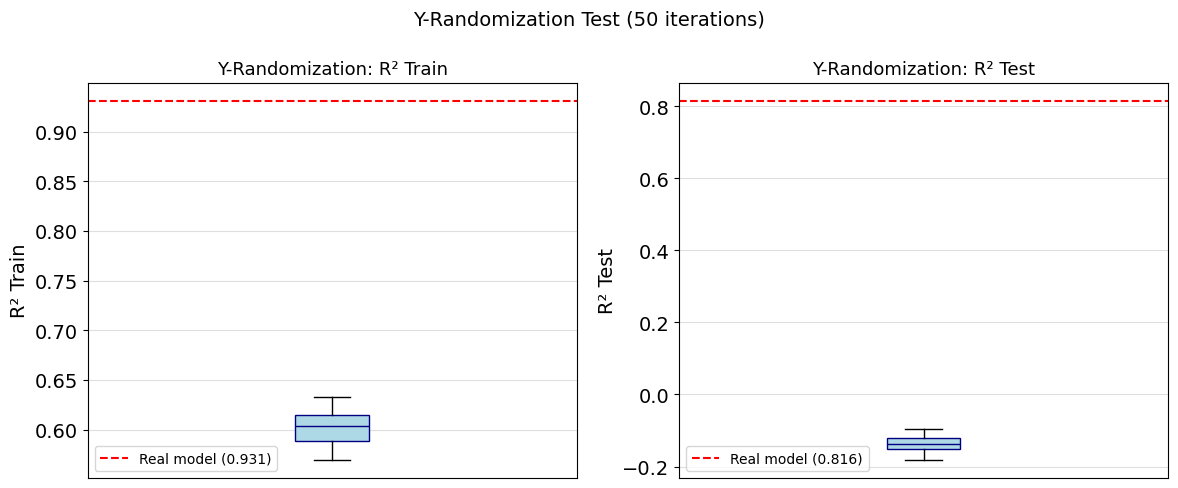

In [ ]:
# Uses best_params from the top model for a fair comparison
best_params = top_model['params']

X_reset = X_temp_filtered.reset_index(drop=True)
y_reset = y_temp.reset_index(drop=True)

y_randomization_results = []

for i in range(50):   # 50 iterations — more statistically robust than 10
    y_shuffled = y_reset.sample(frac=1.0, random_state=i).reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_reset, y_shuffled, test_size=0.25, random_state=i
    )

    model = LGBMRegressor(random_state=i, **best_params)
    model.fit(X_tr, y_tr)

    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    y_randomization_results.append({
        'iteration':  i + 1,
        'r2_train':   r2_score(y_tr, y_tr_pred),
        'r2_test':    r2_score(y_te, y_te_pred),
        'rmse_train': np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
        'rmse_test':  np.sqrt(mean_squared_error(y_te, y_te_pred)),
    })

y_rand_df = pd.DataFrame(y_randomization_results)
y_rand_df.to_csv("y_randomization_summary.csv", index=False)

print("=== Y-Randomization Results (50 iterations) ===")
print(y_rand_df[['r2_train', 'r2_test', 'rmse_train', 'rmse_test']]
      .agg(['mean', 'std']).round(4))
print(f"\nReal model  →  R² Train: {top_model['r2_train']:.4f} | R² Test: {top_model['r2_test']:.4f}")
print(f"Y-rand mean →  R² Train: {y_rand_df['r2_train'].mean():.4f} | "
      f"R² Test: {y_rand_df['r2_test'].mean():.4f}")

# Boxplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, label, real_val in zip(
    axes,
    ['r2_train', 'r2_test'],
    ['R² Train', 'R² Test'],
    [top_model['r2_train'], top_model['r2_test']]
):
    ax.boxplot(y_rand_df[metric], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='navy'))
    ax.axhline(real_val, color='red', linestyle='--',
               linewidth=1.5, label=f'Real model ({real_val:.3f})')
    ax.set_title(f'Y-Randomization: {label}', fontsize=13)
    ax.set_ylabel(label)
    ax.set_xticks([])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Y-Randomization Test (50 iterations)', fontsize=14)
plt.tight_layout()
plt.savefig("y_randomization_summary_plot.png", dpi=300)
plt.show()

**Model Selection & Finalization**

In [ ]:
import joblib
import json
from sklearn.base import clone

# ────────────────────────────────────────────────────────────
# 1. Apply fitted feature selectors to FULL dataset (no re-fitting)
# ────────────────────────────────────────────────────────────
X_full_reduced = pd.DataFrame(
    vt.transform(X),                         # vt fitted on X_temp only
    columns=X.columns[vt.get_support()],
    index=X.index
)
X_full_filtered = X_full_reduced.drop(columns=to_drop)   # same to_drop from training
X_full_final    = X_full_filtered[top_descriptors]        # same top_descriptors from Step C

print(f"Full dataset after feature selection: {X_full_final.shape}")

# ────────────────────────────────────────────────────────────
# 2. Retrain final model on full dataset using best hyperparameters
# ────────────────────────────────────────────────────────────
final_model = clone(top_model['model'])
final_model.set_params(**top_model['params'])
final_model.fit(X_full_final, y)

# ────────────────────────────────────────────────────────────
# 4. Save model and hyperparameters
# ────────────────────────────────────────────────────────────
joblib.dump(final_model, "finalized_lightgbm_model.pkl")
with open("finalized_lightgbm_hyperparameters.json", 'w') as f:
    json.dump(top_model['params'], f, indent=2)
print("Model saved → finalized_lightgbm_model.pkl")

# ────────────────────────────────────────────────────────────
# 5. Feature importances from final model
# ────────────────────────────────────────────────────────────
feature_importance_df = pd.DataFrame({
    'Feature':    X_full_final.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importance_df.to_csv("finalized_lightgbm_feature_importances.csv", index=False)
print("Feature importances saved → finalized_lightgbm_feature_importances.csv")
print(f"\nBest Params: {top_model['params']}")

Full dataset after feature selection: (5697, 50)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003429 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12252
[LightGBM] [Info] Number of data points in the train set: 5697, number of used features: 50
[LightGBM] [Info] Start training from score 7.490170
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

**External Validation**

=== External Validation Results (LightGBM) ===
  y_train_mean         : 7.4895
  external_target_mean : 7.4549
  ss_res               : 199.0986
  ss_tot_train         : 2213.6606
  ss_tot_external      : 2212.2983
  R² external          : 0.9100
  Q² external          : 0.9101
  RMSE external: 0.4179
  MAE external : 0.2962


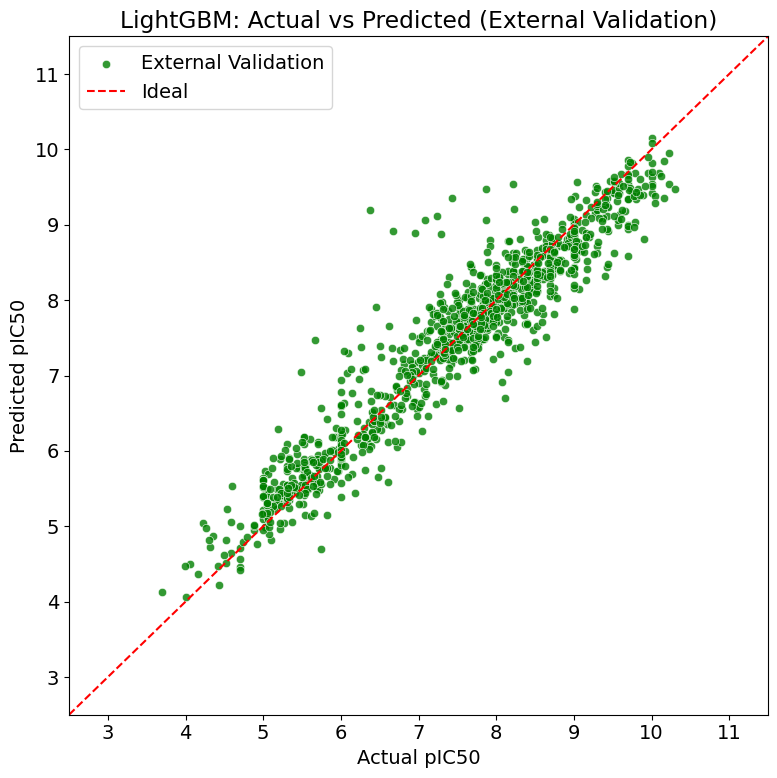

In [ ]:
# ────────────────────────────────────────────────────────────
# 1. Load external validation set
# ────────────────────────────────────────────────────────────
external_df       = pd.read_csv('validation_set_untouched.csv')
external_target   = external_df['Actual'].reset_index(drop=True)
external_features = external_df.drop(columns=['Smiles', 'Actual'], errors='ignore')

# ────────────────────────────────────────────────────────────
# 2. Align to training features
# ────────────────────────────────────────────────────────────
saved_features = pd.read_csv("features_used.csv")['feature'].tolist()

missing = set(saved_features) - set(external_features.columns)
if missing:
    raise ValueError(f"Missing features in external set: {missing}")

external_features = external_features[saved_features]
external_features = external_features.apply(pd.to_numeric, errors='coerce')

if external_features.isnull().any().any():
    print("Warning: NaNs found — imputing with column means")
    external_features = external_features.fillna(external_features.mean())

# ────────────────────────────────────────────────────────────
# 3. Load model and predict
# ────────────────────────────────────────────────────────────
ext_model            = joblib.load("finalized_lightgbm_model.pkl")
external_predictions = ext_model.predict(external_features)

# ────────────────────────────────────────────────────────────
# 4. Load training target to get y_train mean (needed for Q²_ext)
# ────────────────────────────────────────────────────────────
train_df         = pd.read_csv('train_set.csv')           # ← your training CSV
y_train          = train_df['Actual'].reset_index(drop=True)
y_train_mean     = y_train.mean()

# ────────────────────────────────────────────────────────────
# 5. Metrics
#
#   R²      = 1 - SS_res / SS_tot   (test set mean in denominator)
#
#   Q²_ext  = 1 - SS_res / SS_tot   (TRAINING set mean in denominator)
#             — strict QSAR/QSPR definition (Golbraikh & Tropsha, 2002)
# ────────────────────────────────────────────────────────────
ext_r2   = r2_score(external_target, external_predictions)
ext_rmse = np.sqrt(mean_squared_error(external_target, external_predictions))
ext_mae  = mean_absolute_error(external_target, external_predictions)

# Strict Q²_ext formula
ss_res      = np.sum((external_target - external_predictions) ** 2)
ss_tot_train = np.sum((external_target - y_train_mean) ** 2)   # ← training mean
ext_q2_ext  = 1 - (ss_res / ss_tot_train)

print("=== External Validation Results (LightGBM) ===")
print(f"  y_train_mean         : {y_train_mean:.4f}")
print(f"  external_target_mean : {external_target.mean():.4f}")
print(f"  ss_res               : {ss_res:.4f}")
print(f"  ss_tot_train         : {ss_tot_train:.4f}")
print(f"  ss_tot_external      : {np.sum((external_target - external_target.mean())**2):.4f}")
print(f"  R² external          : {ext_r2:.4f}")
print(f"  Q² external          : {ext_q2_ext:.4f}")
print(f"  RMSE external: {ext_rmse:.4f}")
print(f"  MAE external : {ext_mae:.4f}")

pd.DataFrame([{
    'R2_external':   round(ext_r2,     4),
    'Q2_external':   round(ext_q2_ext, 4),
    'RMSE_external': round(ext_rmse,   4),
    'MAE_external':  round(ext_mae,    4)
}]).to_csv('external_validation_lightgbm_results.csv', index=False)

# ────────────────────────────────────────────────────────────
# 6. Save predictions
# ────────────────────────────────────────────────────────────
results_ext = external_df.copy().reset_index(drop=True)
results_ext['Predicted_pIC50'] = external_predictions
results_ext.to_csv('predicted_activity_external_lightgbm.csv', index=False)

# ────────────────────────────────────────────────────────────
# 7. Plot
# ────────────────────────────────────────────────────────────
axis_min = float(np.floor(min(external_target.min(), external_predictions.min()))) - 0.5
axis_max = float(np.ceil( max(external_target.max(), external_predictions.max()))) + 0.5

plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 14})
sns.scatterplot(x=external_target, y=external_predictions,
                color='green', alpha=0.8, label='External Validation')
plt.plot([axis_min, axis_max], [axis_min, axis_max], '--r', label='Ideal')
plt.xlim(axis_min, axis_max)
plt.ylim(axis_min, axis_max)
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title("LightGBM: Actual vs Predicted (External Validation)")
plt.legend()
plt.tight_layout()
plt.savefig('external_validation_lightgbm_plot.png', dpi=300)
plt.show()

**Model Interpretation and Descriptor Analysis**

Top 20 descriptors influencing pIC50 prediction:
   Feature  Importance
SpMax3_Bhm         119
    AATS7m         110
     SdssC         105
    ATSC6p         102
    ATSC2c          98
    maxHBa          97
     XLogP          97
    GATS5c          96
    ATSC8v          94
      GGI7          93
    ATSC4c          93
     VCH-7          92
    ATSC8s          87
    AATS8i          86
    ATSC7c          86
    ATSC4i          85
     ALogP          84
    GATS6e          83
    ATSC7p          82
    ATSC7e          82


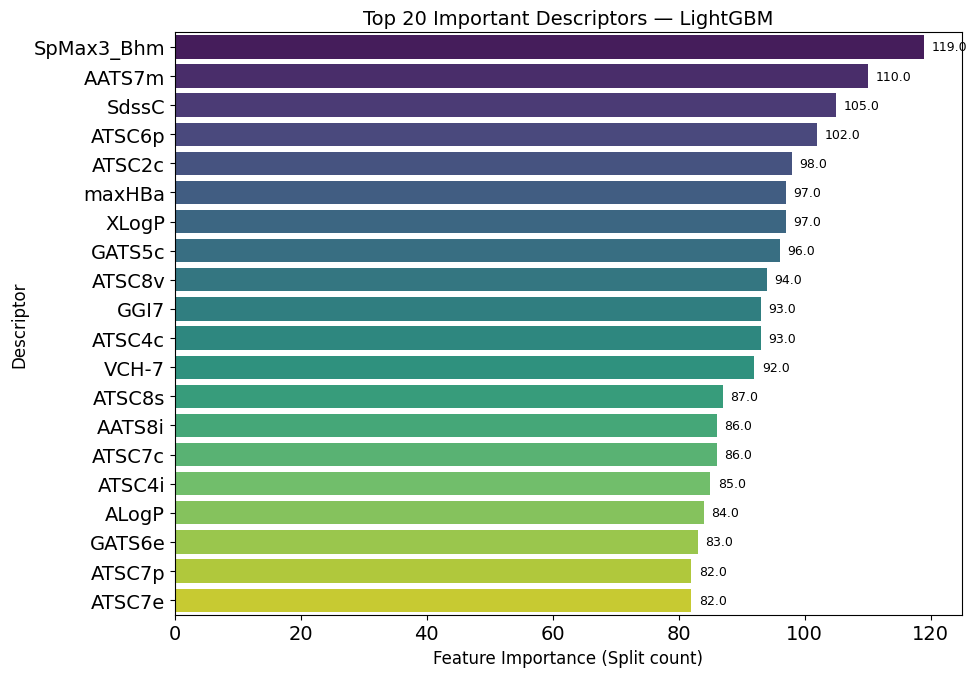

Feature importance plot saved.


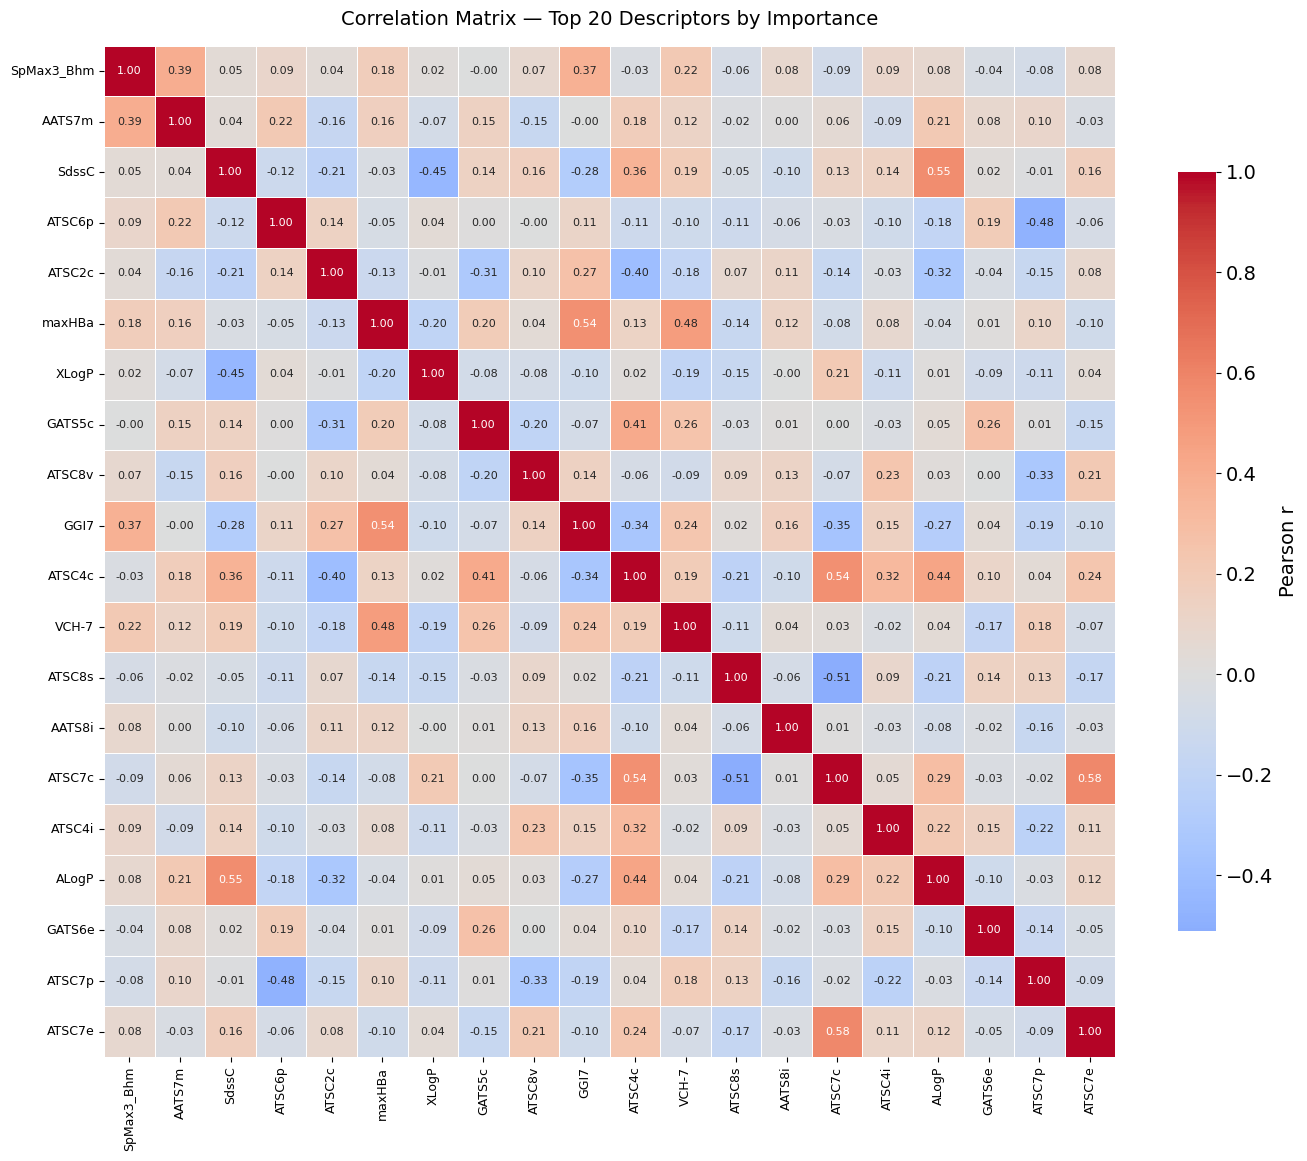

Correlation matrix saved → correlation_matrix_top20_descriptors.png
Correlation matrix data saved → correlation_matrix_top20.csv


In [ ]:
# ────────────────────────────────────────────────────────────
# 1. Load feature importances
# ────────────────────────────────────────────────────────────
feature_importance_df = pd.read_csv("finalized_lightgbm_feature_importances.csv")

top_n           = min(20, len(feature_importance_df))
top_features_df = feature_importance_df.head(top_n).reset_index(drop=True)

print(f"Top {top_n} descriptors influencing pIC50 prediction:")
print(top_features_df.to_string(index=False))

# ────────────────────────────────────────────────────────────
# 2. Feature importance bar plot
# ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=top_features_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)
for i, val in enumerate(top_features_df['Importance']):
    ax.text(val + max(top_features_df['Importance']) * 0.01,
            i, f'{val:.1f}', va='center', fontsize=9)

plt.title(f"Top {top_n} Important Descriptors — LightGBM", fontsize=14)
plt.xlabel("Feature Importance (Split count)", fontsize=12)
plt.ylabel("Descriptor", fontsize=12)
plt.tight_layout()
plt.savefig("top_descriptors_lightgbm.png", dpi=300)
plt.show()
print("Feature importance plot saved.")

# ────────────────────────────────────────────────────────────
# 3. Correlation matrix of top 20 features
#    Uses training data (already feature-selected, no leakage)
# ────────────────────────────────────────────────────────────
train_df_corr = pd.read_csv('train_set.csv')

# Get top 20 feature names from importance ranking
top20_feature_names = feature_importance_df['Feature'].head(20).tolist()

# Keep only those that exist in train_set.csv (excludes Actual/Predicted/Set/Smiles)
available_features  = [f for f in top20_feature_names if f in train_df_corr.columns]
corr_data           = train_df_corr[available_features]
corr_matrix_top20   = corr_data.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix_top20, dtype=bool), k=1)   # upper triangle mask (optional: show full)

sns.heatmap(
    corr_matrix_top20,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.4,
    linecolor='white',
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90,  fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=9)
ax.set_title('Correlation Matrix — Top 20 Descriptors by Importance',
             fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("correlation_matrix_top20_descriptors.png", dpi=300)
plt.show()
print("Correlation matrix saved → correlation_matrix_top20_descriptors.png")

# Save correlation matrix as CSV too
corr_matrix_top20.round(4).to_csv("correlation_matrix_top20.csv")
print("Correlation matrix data saved → correlation_matrix_top20.csv")

**Applicability Domain (AD)**

**Leverage Method (Williams Plot)**

Leverage threshold h* = 3(p+1)/n = 0.0448


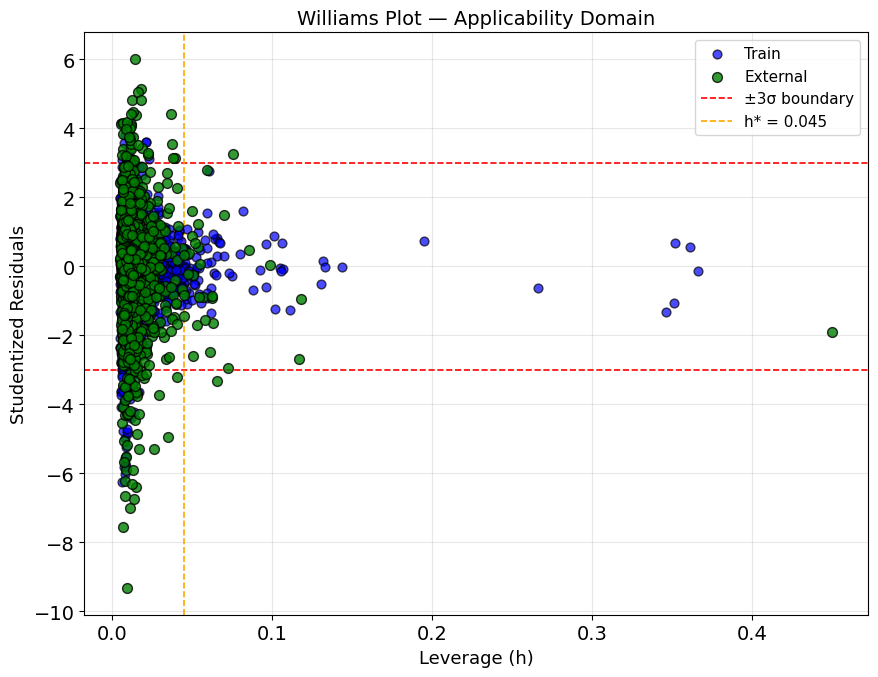

Training compounds outside AD : 128 / 3417
External compounds outside AD : 116 / 1140


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ────────────────────────────────────────────────────────────
# 1. Load train data from best model
# ────────────────────────────────────────────────────────────
X_train_ad = top_model['X_train'].reset_index(drop=True)
y_train_ad = top_model['y_train'].reset_index(drop=True)
y_pred_ad  = top_model['y_train_pred']

# Mean-center X_train before leverage (important for correctness)
train_mean   = X_train_ad.mean()
X_train_c    = (X_train_ad - train_mean).to_numpy()

# ────────────────────────────────────────────────────────────
# 2. Leverage via QR decomposition (numerically stable)
# ────────────────────────────────────────────────────────────
Q, R           = np.linalg.qr(X_train_c)
leverage_train = np.sum(Q**2, axis=1)   # diagonal of hat matrix H = QQᵀ

# ────────────────────────────────────────────────────────────
# 3. Studentized residuals
# ────────────────────────────────────────────────────────────
residuals_train   = y_train_ad.values - y_pred_ad
sigma             = np.std(residuals_train)
std_res_train     = residuals_train / (
    sigma * np.sqrt(np.clip(1 - leverage_train, 1e-10, None))
)

# ────────────────────────────────────────────────────────────
# 4. Leverage threshold h* = 3(p+1)/n
# ────────────────────────────────────────────────────────────
n_tr, p_tr   = X_train_ad.shape
h_threshold  = 3 * (p_tr + 1) / n_tr
print(f"Leverage threshold h* = 3(p+1)/n = {h_threshold:.4f}")

# ────────────────────────────────────────────────────────────
# 5. Leverage for external/validation set
#    Center using training mean (no leakage)
# ────────────────────────────────────────────────────────────
XtX_inv  = np.linalg.pinv(X_train_c.T @ X_train_c)
X_ext_c  = (X_val_filtered.reset_index(drop=True) - train_mean).to_numpy()
leverage_ext = np.einsum('ij,jk,ik->i', X_ext_c, XtX_inv, X_ext_c)

y_val_pred_ad  = top_model['model'].predict(X_val_filtered)
residuals_ext  = y_val.values - y_val_pred_ad
std_res_ext    = residuals_ext / (
    sigma * np.sqrt(np.clip(1 - leverage_ext, 1e-10, None))
)

# ────────────────────────────────────────────────────────────
# 6. Williams Plot
# ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
plt.scatter(leverage_train, std_res_train,
            c='blue', edgecolors='k', s=40, alpha=0.7, label='Train', zorder=3)
plt.scatter(leverage_ext, std_res_ext,
            c='green', edgecolors='k', s=50, alpha=0.8, label='External', zorder=3)
plt.axhline(y= 3, color='red',    linestyle='--', linewidth=1.2, label='±3σ boundary')
plt.axhline(y=-3, color='red',    linestyle='--', linewidth=1.2)
plt.axvline(x=h_threshold, color='orange', linestyle='--',
            linewidth=1.2, label=f'h* = {h_threshold:.3f}')
plt.xlabel("Leverage (h)", fontsize=13)
plt.ylabel("Studentized Residuals", fontsize=13)
plt.title("Williams Plot — Applicability Domain", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("williams_plot.png", dpi=300)
plt.show()

# ────────────────────────────────────────────────────────────
# 7. Save compounds outside AD
# ────────────────────────────────────────────────────────────
outside_train = (np.abs(std_res_train) > 3) | (leverage_train > h_threshold)
outside_ext   = (np.abs(std_res_ext)   > 3) | (leverage_ext   > h_threshold)

# ── Training compounds outside AD ──
outside_train_df = X_train_ad[outside_train].copy()
outside_train_df['Residual'] = residuals_train[outside_train]
outside_train_df['Leverage'] = leverage_train[outside_train]

# Add SMILES if available
if top_model['smiles_train'] is not None:
    smiles_train_reset = top_model['smiles_train'].reset_index(drop=True)
    outside_train_df.insert(0, 'Smiles', smiles_train_reset[outside_train].values)

outside_train_df.to_csv("training_compounds_outside_ad.csv", index=False)

# ── External compounds outside AD ──
outside_ext_df = X_val_filtered.reset_index(drop=True)[outside_ext].copy()
outside_ext_df['Residual'] = residuals_ext[outside_ext]
outside_ext_df['Leverage'] = leverage_ext[outside_ext]

# Add SMILES if available
if smiles_val is not None:
    smiles_val_reset = smiles_val.reset_index(drop=True)
    outside_ext_df.insert(0, 'Smiles', smiles_val_reset[outside_ext].values)

outside_ext_df.to_csv("external_compounds_outside_ad.csv", index=False)

print(f"Training compounds outside AD : {outside_train.sum()} / {n_tr}")
print(f"External compounds outside AD : {outside_ext.sum()} / {len(leverage_ext)}")

**Distance-Based Method (Mahalanobis Distance)**

Mahalanobis threshold (χ² 95%, df=2): 2.4477


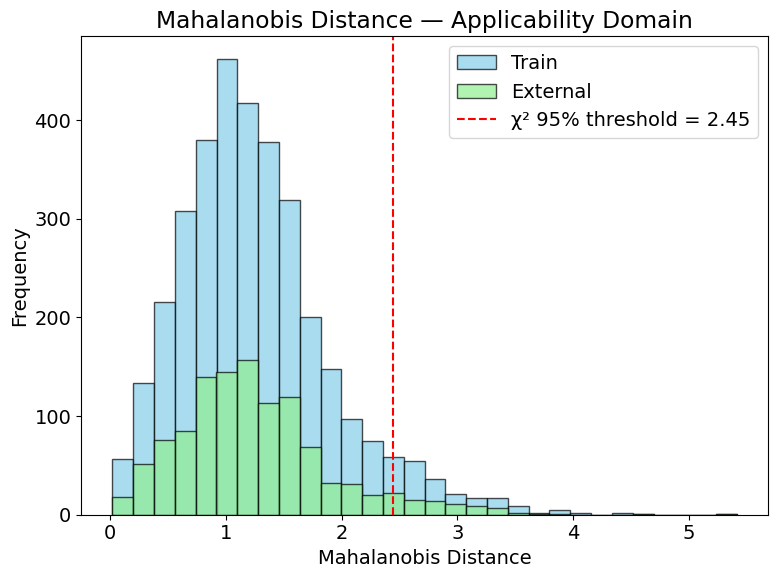

Train compounds outside AD : 201 / 3417
External compounds outside AD : 72 / 1140


In [ ]:
from scipy.spatial import distance
from scipy.stats import chi2
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────
# 1. Reduce dimensions with PCA first — FIX #1
#    (avoids singular covariance in high-dim QSAR data)
# ─────────────────────────────────────────────
X_train_reset = X_train.reset_index(drop=True)
X_train_np    = X_train_reset.to_numpy()

pca = PCA(n_components=0.95, random_state=42)   # retain 95% variance
X_train_pca = pca.fit_transform(X_train_np)

# ─────────────────────────────────────────────
# 2. Covariance and inverse on PCA-reduced data
# ─────────────────────────────────────────────
mean_vector    = np.mean(X_train_pca, axis=0)
cov_matrix     = np.atleast_2d(np.cov(X_train_pca, rowvar=False)) # Ensure cov_matrix is always 2D
inv_cov_matrix = np.linalg.pinv(cov_matrix)

# ─────────────────────────────────────────────
# 3. Vectorized Mahalanobis — FIX #5
# ─────────────────────────────────────────────
def mahal_vectorized(X, mean, inv_cov):
    diff = X - mean
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))

mahal_train = mahal_vectorized(X_train_pca, mean_vector, inv_cov_matrix)

# ─────────────────────────────────────────────
# 4. Chi-squared threshold — FIX #2
#    D²_M ~ chi²(p) where p = number of PCA components
# ─────────────────────────────────────────────
n_components = X_train_pca.shape[1]
threshold    = np.sqrt(chi2.ppf(0.95, df=n_components))
print(f"Mahalanobis threshold (χ² 95%, df={n_components}): {threshold:.4f}")

# ─────────────────────────────────────────────
# 5. Apply to external/validation set — FIX #3
# ─────────────────────────────────────────────
X_ext_np  = X_val_filtered.reset_index(drop=True).to_numpy()
X_ext_pca = pca.transform(X_ext_np)   # use fitted PCA — no re-fitting
mahal_ext = mahal_vectorized(X_ext_pca, mean_vector, inv_cov_matrix)

# ─────────────────────────────────────────────
# 6. Plot — FIX #7: overlay both distributions
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.hist(mahal_train, bins=30, color='skyblue',
         edgecolor='black', alpha=0.7, label='Train')
plt.hist(mahal_ext,   bins=30, color='lightgreen',
         edgecolor='black', alpha=0.7, label='External')
plt.axvline(x=threshold, color='red', linestyle='--',
            label=f'χ² 95% threshold = {threshold:.2f}')
plt.title("Mahalanobis Distance — Applicability Domain")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("mahalanobis_ad.png", dpi=300)
plt.show()

# ─────────────────────────────────────────────
# 7. Save outliers — FIX #4: reset index before masking
# ─────────────────────────────────────────────
md_outliers_train = mahal_train > threshold
md_outliers_ext   = mahal_ext   > threshold

# ── Training outliers ──
train_outliers_df = X_train_reset[md_outliers_train].copy()
train_outliers_df['Mahalanobis_Distance'] = mahal_train[md_outliers_train]

if top_model['smiles_train'] is not None:
    smiles_train_reset = top_model['smiles_train'].reset_index(drop=True)
    train_outliers_df.insert(0, 'Smiles', smiles_train_reset[md_outliers_train].values)

train_outliers_df.to_csv("mahalanobis_train_outliers.csv", index=False)

# ── External outliers ──
ext_outliers_df = X_val_filtered.reset_index(drop=True)[md_outliers_ext].copy()
ext_outliers_df['Mahalanobis_Distance'] = mahal_ext[md_outliers_ext]

if smiles_val is not None:
    smiles_val_reset = smiles_val.reset_index(drop=True)
    ext_outliers_df.insert(0, 'Smiles', smiles_val_reset[md_outliers_ext].values)

ext_outliers_df.to_csv("mahalanobis_external_outliers.csv", index=False)

print(f"Train compounds outside AD : {md_outliers_train.sum()} / {len(mahal_train)}")
print(f"External compounds outside AD : {md_outliers_ext.sum()} / {len(mahal_ext)}")